### Configure API Client

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv("BINANCE_API_KEY")
api_secret = os.getenv("BINANCE_SECRET_KEY")

In [3]:
from binance.client import Client
client = Client(api_key, api_secret, testnet=True)

### Load Data

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("../data/raw_ohlcv/BTCUSDT-1h-2017-08-17.csv", index_col='Date', parse_dates=['Date'])
df = df[["Close", "Volume"]].copy()

In [6]:
df.head()

,Close,Volume
Date,,
2017-08-17 04:00:00,4308.83,47.181009
2017-08-17 05:00:00,4315.32,23.234916
2017-08-17 06:00:00,4324.35,7.229691
2017-08-17 07:00:00,4349.99,4.443249
2017-08-17 08:00:00,4360.69,0.972807


### Calculating Returns

In [7]:
import numpy as np

In [8]:
df["Return"] = df["Close"].div(df["Close"].shift(1))     # This is the return factor from that period's interval
df["Return"] = np.log(df["Return"])    # Converts to log returns for additivity and scale
df

,Close,Volume,Return
Date,,,
2017-08-17 04:00:00,4308.83,47.181009,NaN
2017-08-17 05:00:00,4315.32,23.234916,0.001505
2017-08-17 06:00:00,4324.35,7.229691,0.002090
2017-08-17 07:00:00,4349.99,4.443249,0.005912
2017-08-17 08:00:00,4360.69,0.972807,0.002457
...,...,...,...
2026-01-22 02:00:00,89938.30,436.559460,-0.001943
2026-01-22 03:00:00,89899.51,389.701230,-0.000431
2026-01-22 04:00:00,89998.91,327.010220,0.001105


### Visualising Data


In [9]:
import matplotlib.pyplot as plt

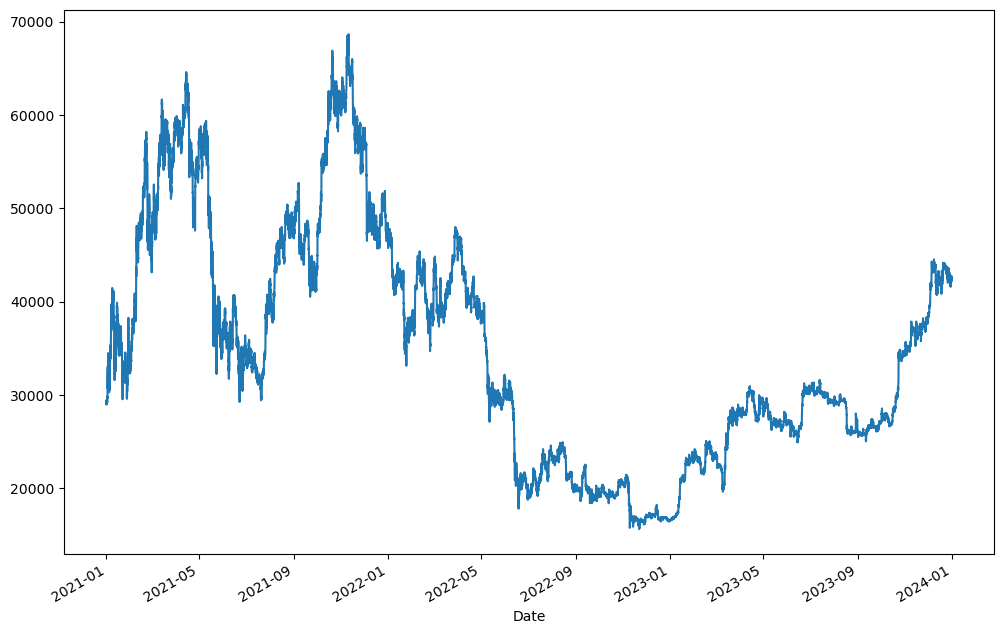

In [10]:
df.Close.loc['2021':'2023'].plot(figsize=(12,8))
plt.show()

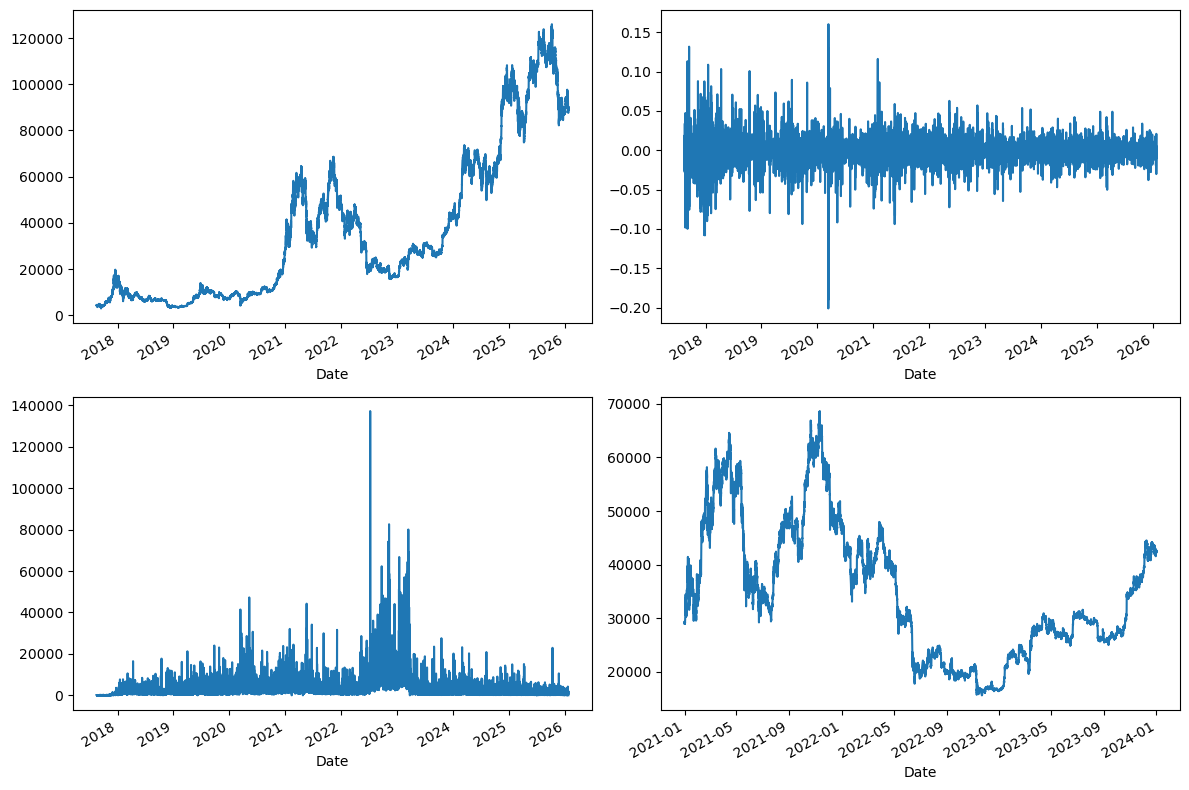

In [11]:
fig, axs = plt.subplots(2,2, figsize=(12,8))

df.Close.plot(ax=axs[0,0])
df.Volume.plot(ax=axs[1,0])
df.Close.loc['2021':'2023'].plot(ax=axs[1,1])
df.Return.plot(ax=axs[0,1])

plt.tight_layout()
plt.show()

### Buy and Hold Strategy

In [12]:
# Normalise Close price with respect to the first price - effectively the multiple at that time
normalised_price_series = df.Close / df.Close.iloc[0]     

In [13]:
# Calculating the multiple directly
multiple = np.exp(df["Return"].sum())
multiple

np.float64(20.876567420854414)

In [14]:
# Cumulative return from buying and holding
df['C_return'] = df['Return'].cumsum().apply(np.exp)
df

,Close,Volume,Return,C_return
Date,,,,
2017-08-17 04:00:00,4308.83,47.181009,NaN,NaN
2017-08-17 05:00:00,4315.32,23.234916,0.001505,1.001506
2017-08-17 06:00:00,4324.35,7.229691,0.002090,1.003602
2017-08-17 07:00:00,4349.99,4.443249,0.005912,1.009552
2017-08-17 08:00:00,4360.69,0.972807,0.002457,1.012036
...,...,...,...,...
2026-01-22 02:00:00,89938.30,436.559460,-0.001943,20.873021
2026-01-22 03:00:00,89899.51,389.701230,-0.000431,20.864019
2026-01-22 04:00:00,89998.91,327.010220,0.001105,20.887088


### Backtesting Random Strategy

#### Backtester

In [15]:
# Using a subset of data (only 2021) for testing
data = df.loc['2021'].copy()
data['C_return'] = data['Return'].cumsum().apply(np.exp)
data

,Close,Volume,Return,C_return
Date,,,,
2021-01-01 00:00:00,28995.13,2311.811445,0.002469,1.002472
2021-01-01 01:00:00,29409.99,5403.068471,0.014207,1.016815
2021-01-01 02:00:00,29194.65,2384.231560,-0.007349,1.009370
2021-01-01 03:00:00,29278.40,1461.345077,0.002865,1.012266
2021-01-01 04:00:00,29220.31,2038.046803,-0.001986,1.010257
...,...,...,...,...
2021-12-31 19:00:00,45728.28,3851.309020,-0.020736,1.581001
2021-12-31 20:00:00,45879.24,1831.412020,0.003296,1.586220
2021-12-31 21:00:00,46333.86,1734.695850,0.009860,1.601938


In [16]:
data['Position'] = 1

In [17]:
# Random strategy - sells when the close price is mod 10
sell_condition = data['Close'] % 10 == 0

In [18]:
data.loc[sell_condition, 'Position'] = 0

In [19]:
# Checks to see how many times the strategy is not holding
data.Position.value_counts()

Position
1    8535
0     212
Name: count, dtype: int64

In [20]:
data['Strategy'] = data['Position'].shift(1) * data['Return']

In [21]:
data['C_strategy'] = data['Strategy'].cumsum().apply(np.exp)

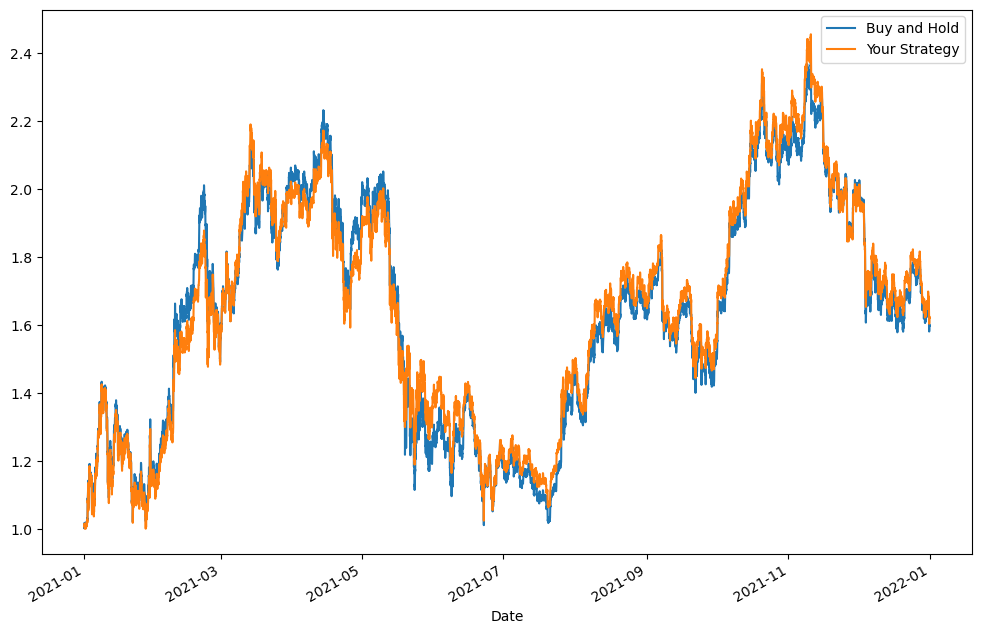

In [22]:
data[['C_return', 'C_strategy']].plot(figsize=(12,8))
plt.legend(['Buy and Hold', 'Your Strategy'])
plt.show()

#### Performance Metrics

In [23]:
# Number of trading periods
trading_periods = 8760

##### Annaulised Mean

In [24]:
ann_mean_log = data[['Return', 'Strategy']].mean() * trading_periods
ann_mean = np.exp(ann_mean_log) - 1
ann_mean

Return      0.599009
Strategy    0.622302
dtype: float64

##### Standard Deviation

In [25]:
ann_std = data[['Return', 'Strategy']].std() * np.sqrt(trading_periods)
ann_std

Return      0.861504
Strategy    0.847011
dtype: float64

##### Sharpe Ratio

In [26]:
sharpe = (ann_mean / ann_std)
sharpe

Return      0.695306
Strategy    0.734704
dtype: float64

#### Trading Costs

In [54]:
commission = 0.1 / 100

In [55]:
ptc = np.log(1 - commission)

In [56]:
data['Trade'] = data['Position'].diff().fillna(0).abs()

In [57]:
data['Strategy_net'] = data['Strategy'] + data['Trade'] * ptc

In [58]:
data['C_strategy_net'] = data['Strategy_net'].cumsum().apply(np.exp)

In [59]:
data.C_strategy_net.nlargest(10)

Date
2021-03-13 20:00:00    2.030443
2021-03-14 03:00:00    2.020827
2021-03-14 00:00:00    2.017671
2021-03-14 04:00:00    2.016520
2021-03-13 23:00:00    2.015297
2021-03-13 21:00:00    2.014067
2021-03-13 22:00:00    2.012255
2021-03-14 01:00:00    2.011760
2021-03-14 02:00:00    2.011110
2021-03-14 05:00:00    2.009628
Name: C_strategy_net, dtype: float64

In [60]:
data.C_strategy.nlargest(10)

Date
2021-11-10 17:00:00    2.456178
2021-11-10 16:00:00    2.452277
2021-11-10 14:00:00    2.447195
2021-11-10 15:00:00    2.445976
2021-11-09 03:00:00    2.442422
2021-11-09 04:00:00    2.442422
2021-11-09 09:00:00    2.441373
2021-11-09 05:00:00    2.436986
2021-11-09 13:00:00    2.436376
2021-11-09 08:00:00    2.435942
Name: C_strategy, dtype: float64

In [61]:
data

,Close,Volume,Return,C_return,Position,Strategy,C_strategy,Trade,Strategy_net,C_strategy_net
Date,,,,,,,,,,
2021-01-01 00:00:00,28995.13,2311.811445,0.002469,1.002472,1,NaN,NaN,0.0,NaN,NaN
2021-01-01 01:00:00,29409.99,5403.068471,0.014207,1.016815,1,0.014207,1.014308,0.0,0.014207,1.014308
2021-01-01 02:00:00,29194.65,2384.231560,-0.007349,1.009370,1,-0.007349,1.006881,0.0,-0.007349,1.006881
2021-01-01 03:00:00,29278.40,1461.345077,0.002865,1.012266,1,0.002865,1.009770,0.0,0.002865,1.009770
2021-01-01 04:00:00,29220.31,2038.046803,-0.001986,1.010257,1,-0.001986,1.007766,0.0,-0.001986,1.007766
...,...,...,...,...,...,...,...,...,...,...
2021-12-31 19:00:00,45728.28,3851.309020,-0.020736,1.581001,1,-0.020736,1.603909,0.0,-0.020736,1.057847
2021-12-31 20:00:00,45879.24,1831.412020,0.003296,1.586220,1,0.003296,1.609204,0.0,0.003296,1.061339
2021-12-31 21:00:00,46333.86,1734.695850,0.009860,1.601938,1,0.009860,1.625150,0.0,0.009860,1.071856


<Axes: xlabel='Date'>

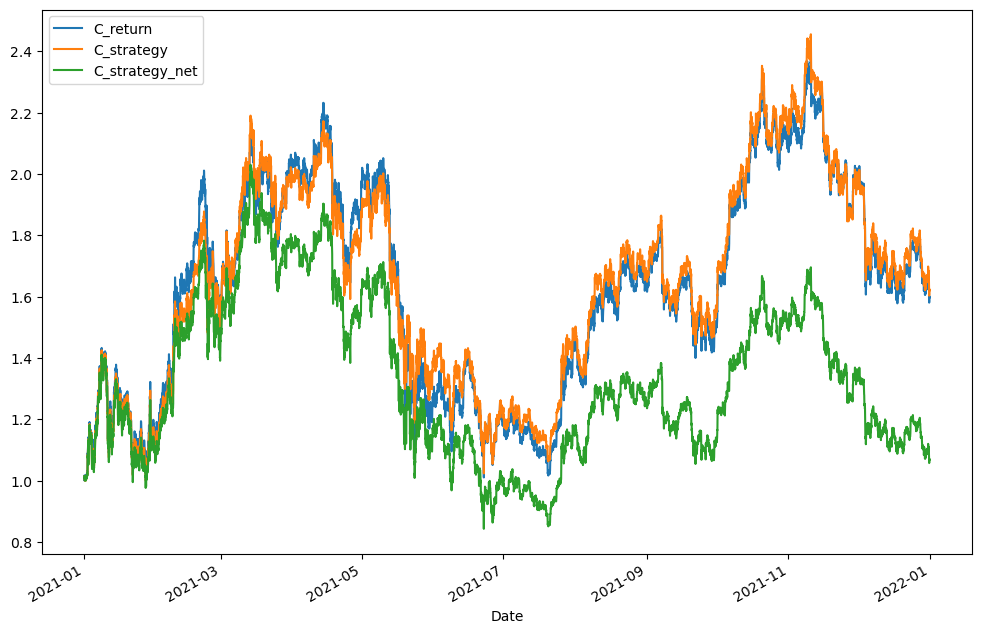

In [62]:
data[['C_return', 'C_strategy', 'C_strategy_net']].plot(figsize=(12,8))